In [16]:
#importing required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
from scipy.optimize import linprog

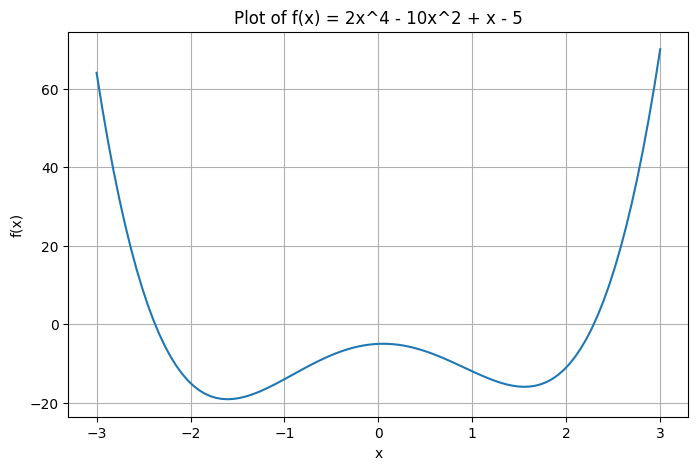

Minimum occurs at x = -1.605569766752713
Minimum value of f(x) = -19.09344719019766


In [4]:
#defining the function
def f(x):
    return 2*x**4 - 10*x**2 + x - 5

#generating x values for plotting
x_vals = np.linspace(-3, 3, 100)
y_vals = f(x_vals)

#plotting the function
plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Plot of f(x) = 2x^4 - 10x^2 + x - 5")
plt.grid(True)
plt.show()

#finding the minimum using SciPy
result = minimize_scalar(f, bounds=(-3, 3), method='bounded')

#prrinting results
print("Minimum occurs at x =", result.x)
print("Minimum value of f(x) =", result.fun)


## Methodology

The solution is obtained using the following steps:

1. The function \( f(x) \) is defined in Python.
2. The function is plotted over the interval \( [-3, 3] \) to visually examine its behavior.
3. The SciPy function `minimize_scalar()` is used with the bounded method to locate the global minimum of the function within the specified interval.
4. The numerical result is interpreted using both the optimization output and the plotted curve.


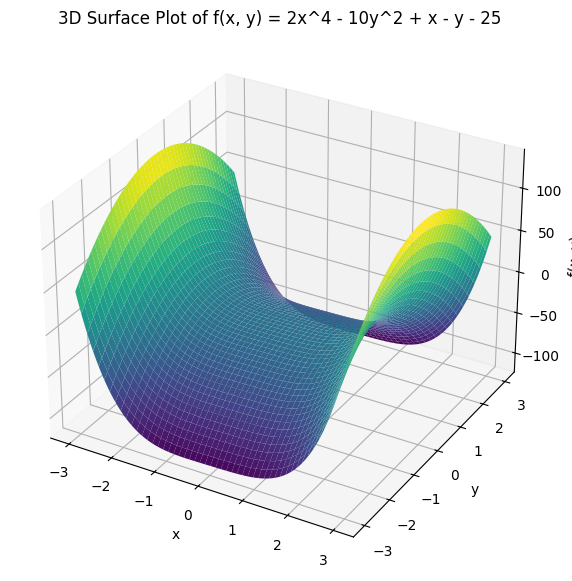

In [7]:
#defining the function
def f(x, y):
    return 2*x**4 - 10*y**2 + x - y - 25

#creating a grid of (x, y) values
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)

#computing f(x, y)
Z = f(X, Y)

#creating 3D surface plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

#labeling axes
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.set_title('3D Surface Plot of f(x, y) = 2x^4 - 10y^2 + x - y - 25')

plt.show()

### Methodology (Q2a)

Generated a grid of \((x, y)\) values over the domain  
\[
[-3, 3] x [-3, 3]
\]
evaluated \( f(x, y) \) on the grid, and plotted the resulting surface using
`Axes3D` from `mpl_toolkits.mplot3d` with the `plot_surface` function.


In [9]:
#defining the function
def f_xy(vars_):
    x, y = vars_
    return 2*x**4 - 10*y**2 + x - y - 25

#negative function for maximization
def neg_f_xy(vars_):
    return -f_xy(vars_)

#box constraints
bounds = [(-3, 3), (-3, 3)]

#initial guess
x0 = [0, 0]

#constrained minimum
min_result = minimize(
    f_xy,
    x0=x0,
    method="L-BFGS-B",
    bounds=bounds
)

#constrained maximum (minimize -f)
max_result = minimize(
    neg_f_xy,
    x0=x0,
    method="L-BFGS-B",
    bounds=bounds
)

#printing results
print("Constrained Minimum:")
print("x =", min_result.x[0])
print("y =", min_result.x[1])
print("f(x,y) =", min_result.fun)

print("\nConstrained Maximum:")
print("x =", max_result.x[0])
print("y =", max_result.x[1])
print("f(x,y) =", -max_result.fun)

Constrained Minimum:
x = -0.4999974167503352
y = 3.0
f(x,y) = -118.37499999997998

Constrained Maximum:
x = 3.0
y = -0.04999963034220081
f(x,y) = 140.02499999999864


### Methodology (Q2b)

The unconstrained minimum and maximum of
$$
f(x,y) = 2x^4 - 10y^2 + x - y - 25
$$
do not exist because
$$
f(x,y) \to -\infty \quad \text{as} \quad |y| \to \infty,
$$
and
$$
f(x,y) \to +\infty \quad \text{as} \quad |x| \to \infty.
$$

Therefore, box constraints were added:
$$
x \in [-3,3], \quad y \in [-3,3].
$$

The constrained minimum was found by minimizing \( f(x,y) \) on this domain.  
The constrained maximum was found by minimizing \( -f(x,y) \) on the same domain.


In [12]:
methods = ["SLSQP", "Powell"]
comparison_results = {}

for method in methods:
    res = minimize(
        f_xy,
        x0=x0,
        method=method,
        bounds=bounds
    )
    comparison_results[method] = res

print("Comparison for Minimization from different methods")
print("\nPrimary Method: L-BFGS-B")
print("x =", min_result.x[0])
print("y =", min_result.x[1])
print("f(x,y) =", min_result.fun)

for method, res in comparison_results.items():
    print(f"\nMethod: {method}")
    print("x =", res.x[0])
    print("y =", res.x[1])
    print("f(x,y) =", res.fun)
    print("success =", res.success)

Comparison for Minimization from different methods

Primary Method: L-BFGS-B
x = -0.4999974167503352
y = 3.0
f(x,y) = -118.37499999997998

Method: SLSQP
x = -0.5000239636842523
y = 3.0
f(x,y) = -118.37499999827718
success = True

Method: Powell
x = -0.500019424765397
y = 2.999999996721291
f(x,y) = -118.37499979886675
success = True


### Method Choice and Interpretation (Q2c)

The constrained minimum of \( f(x,y) \) was computed using **L-BFGS-B** as
the primary optimization method because it directly supports box constraints
and is efficient for smooth functions.

To check whether the result depends on the optimization algorithm, the same
minimization was performed using **SLSQP** and **Powell** under the same
constraints.

All methods converged to the same minimizer,
\[
(x^*, y^*) \approx (-0.5, 3.0),
\]
with minimum value
\[
f(x^*, y^*) \approx -118.37.
\]
The small differences across methods are due to numerical tolerances, showing
that the constrained minimum is stable and method-independent.


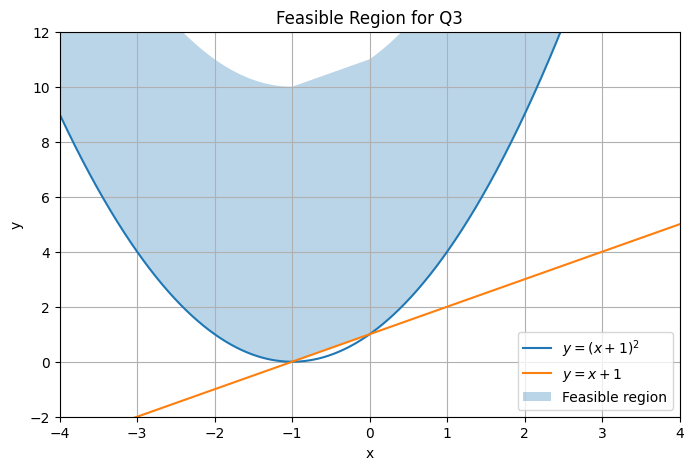

In [13]:
#defining x range
x = np.linspace(-4, 4, 800)

#xonstraint boundaries
y_parabola = (x + 1)**2      # y = (x+1)^2
y_line = x + 1              # y = x + 1

#feasible region boundary: y >= max((x+1)^2, x+1)
y_boundary = np.maximum(y_parabola, y_line)

#plotting constraints
plt.figure(figsize=(8, 5))
plt.plot(x, y_parabola, label=r"$y = (x+1)^2$")
plt.plot(x, y_line, label=r"$y = x + 1$")

#shading feasible region (above boundary)
plt.fill_between(
    x,
    y_boundary,
    y_boundary + 10,
    alpha=0.3,
    label="Feasible region"
)

#labeling and formatting
plt.xlabel("x")
plt.ylabel("y")
plt.title("Feasible Region for Q3")
plt.legend()
plt.grid(True)
plt.xlim(-4, 4)
plt.ylim(-2, 12)
plt.show()

### Methodology (Q3a)

The feasible region is defined by the inequality constraints
$$
y \ge (x+1)^2 \quad \text{and} \quad y \ge x+1.
$$

Both constraint boundaries were plotted on the same coordinate system.
The feasible region corresponds to the set of points lying **above both
curves**, which can be written as
$$
y \ge \max\{(x+1)^2,\; x+1\}.
$$

This region was visualized by shading the area above the maximum of the
two boundary curves.


In [14]:
#objective function
def objective(v):
    x, y = v
    return (x - 2)**2 + (y - 1)**2

#inequality constraints (must be >= 0)
constraints = [
    {"type": "ineq", "fun": lambda v: v[1] - (v[0] + 1)**2},  # y >= (x+1)^2
    {"type": "ineq", "fun": lambda v: v[1] - (v[0] + 1)}     # y >= x+1
]

#feasible initial guess
x0 = [0.0, 2.0]

#solveing the constrained optimization problem
result = minimize(
    objective,
    x0=x0,
    method="SLSQP",
    constraints=constraints
)

#printing results
print("Success:", result.success)
print("Optimal x* =", result.x[0])
print("Optimal y* =", result.x[1])
print("Minimum objective value =", result.fun)

Success: True
Optimal x* = 0.28962069296877685
Optimal y* = 1.6631211600713163
Minimum objective value = 3.3651270468549352


### Methodology (Q3b)

The constrained optimization problem was solved using
`scipy.optimize.minimize` with the **SLSQP** method, which is suitable for
nonlinear objectives with inequality constraints.

The objective function and both inequality constraints were provided
explicitly to the optimizer, and a feasible initial guess was used.
The solution returned by the optimizer was then verified by checking that
all constraints were satisfied at the optimal point.


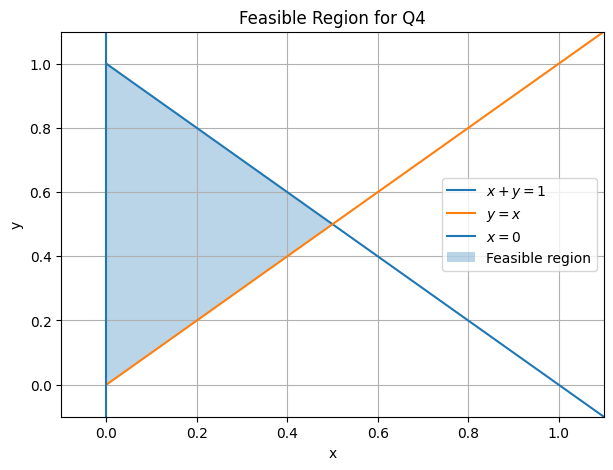

In [15]:
#defining x range
x = np.linspace(0, 1.2, 400)

#constraint boundaries
y_xy = 1 - x      # x + y = 1
y_yx = x          # y = x
x_zero = np.zeros_like(x)  # x = 0

#feasible region is:
# x >= 0, y >= x, y <= 1 - x
x_fill = np.linspace(0, 0.5, 300)
y_lower = x_fill
y_upper = 1 - x_fill

#ploting boundaries
plt.figure(figsize=(7, 5))
plt.plot(x, y_xy, label=r"$x + y = 1$")
plt.plot(x, y_yx, label=r"$y = x$")
plt.axvline(0, label=r"$x = 0$")

#shading feasible region
plt.fill_between(
    x_fill,
    y_lower,
    y_upper,
    alpha=0.3,
    label="Feasible region"
)

#labeling and formatting
plt.xlabel("x")
plt.ylabel("y")
plt.title("Feasible Region for Q4")
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.grid(True)
plt.legend()
plt.show()

### Methodology (Q4a)

The feasible region is determined by the linear constraints
$$
x + y \le 1,\quad y \ge x,\quad x \ge 0.
$$

Each constraint boundary was plotted on the same coordinate system.
The feasible region corresponds to the intersection of these half-spaces,
forming a triangular region bounded by the lines
$$
x + y = 1,\quad y = x,\quad x = 0.
$$
The feasible set was visualized by shading this region.


In [17]:
#minimize: 2x + 3y
c = [2, 3]

#constraints:
#(1) x + y <= 1        -> [1, 1]   <= 1
#(2) y - x >= 0  <=> x - y <= 0    -> [1, -1]  <= 0
A_ub = [
    [1,  1],
    [1, -1]
]
b_ub = [1, 0]

#bounds: x >= 0, y is free but y >= x and x>=0 implies y>=0,
#so set y >= 0 for numerical stability
bounds = [(0, None), (0, None)]

#solving
res = linprog(c=c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")

#printing results
print("Success:", res.success)
print("Message:", res.message)
print("Optimal x* =", res.x[0])
print("Optimal y* =", res.x[1])
print("Minimum value =", res.fun)

Success: True
Message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimal x* = 0.0
Optimal y* = 0.0
Minimum value = 0.0


### Methodology (Q4b)

The linear program was solved using `scipy.optimize.linprog`. The objective
function
$$
\min\; 2x + 3y
$$
was written in vector form with coefficient vector \(c = [2, 3]\).

The constraints were converted to standard inequality form. Specifically,
the constraints \(x + y \le 1\) and \(y - x \ge 0\) were expressed as
$$
x + y \le 1, \quad x - y \le 0.
$$

Nonnegativity bounds were imposed with
$$
x \ge 0, \quad y \ge 0.
$$
The problem was then solved using the HiGHS method within `linprog`, and the
optimal solution and minimum objective value were reported.


Success: True
Message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimal u* (U units) = 20.0
Optimal v* (V units) = 60.0
Maximum weekly profit = 2600.0
Raw material order (grams) = 740.0


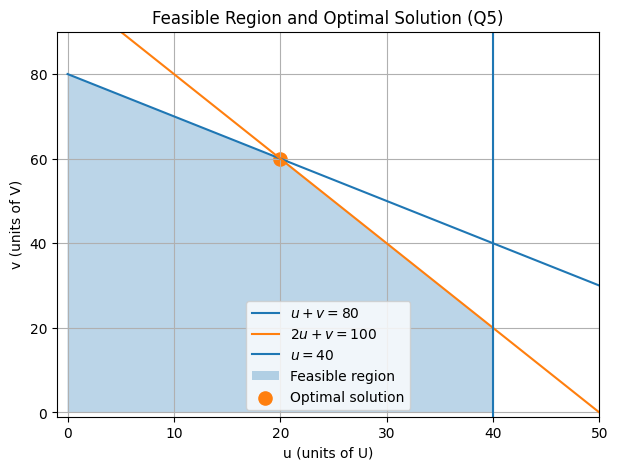


Constraint usage at optimum:
Labor A used (u+v) = 80.0 out of 80
Labor B used (2u+v) = 100.0 out of 100
Demand U used (u) = 20.0 out of 40


In [18]:
#decision variables:
#u = units of product U
#v = units of product V

#profit per unit:
#U: 40, V: 30
#maximize 40u + 30v  <=>  minimize -(40u + 30v)

c = [-40, -30]  #linprog minimizes

#constraints:
#labor A: u + v <= 80
#labor B: 2u + v <= 100
#demand:  u <= 40
A_ub = [
    [1, 1],
    [2, 1],
    [1, 0]
]
b_ub = [80, 100, 40]

#bounds: u >= 0, v >= 0
bounds = [(0, None), (0, None)]

#solving using HiGHS
res = linprog(c=c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")

#extracting solution
u_star, v_star = res.x
max_profit = -res.fun

#raw material order (grams): R = 10u + 9v
raw_order = 10*u_star + 9*v_star

print("Success:", res.success)
print("Message:", res.message)
print("Optimal u* (U units) =", u_star)
print("Optimal v* (V units) =", v_star)
print("Maximum weekly profit =", max_profit)
print("Raw material order (grams) =", raw_order)

#ploting feasible region in (u, v)
#constraints:
#v <= 80 - u
#v <= 100 - 2u
#u <= 40
#u >= 0, v >= 0
u = np.linspace(0, 50, 600)
v_A = 80 - u
v_B = 100 - 2*u

plt.figure(figsize=(7, 5))

#boundary lines
plt.plot(u, v_A, label=r"$u+v=80$")
plt.plot(u, v_B, label=r"$2u+v=100$")
plt.axvline(40, label=r"$u=40$")

#feasible shading: 0 <= v <= min(v_A, v_B), for 0 <= u <= 40
u_fill = np.linspace(0, 40, 500)
v_upper = np.minimum(80 - u_fill, 100 - 2*u_fill)
v_upper = np.maximum(v_upper, 0)  # keep nonnegative

plt.fill_between(u_fill, 0, v_upper, alpha=0.3, label="Feasible region")

#mark optimum
plt.scatter([u_star], [v_star], s=90, label="Optimal solution")

plt.xlim(-1, 50)
plt.ylim(-1, 90)
plt.xlabel("u (units of U)")
plt.ylabel("v (units of V)")
plt.title("Feasible Region and Optimal Solution (Q5)")
plt.grid(True)
plt.legend()
plt.show()


print("\nConstraint usage at optimum:")
print("Labor A used (u+v) =", u_star + v_star, "out of 80")
print("Labor B used (2u+v) =", 2*u_star + v_star, "out of 100")
print("Demand U used (u) =", u_star, "out of 40")

### Methodology (Q5b)

The linear programming model from Q5(a) was solved using
`scipy.optimize.linprog`. Since `linprog` performs minimization, the
profit maximization objective was converted to an equivalent
minimization problem by minimizing the negative profit.

The objective function was:
maximize 40u + 30v  
which was implemented as minimize −(40u + 30v).

All constraints were written in standard inequality form:
u + v ≤ 80  
2u + v ≤ 100  
u ≤ 40  
u ≥ 0, v ≥ 0  

The HiGHS solver was used to obtain the optimal production quantities.
To visualize the feasible region, the boundary lines of the constraints
were plotted in the (u, v) plane and the feasible area was shaded.
The optimal solution point (u*, v*) was highlighted on the plot.


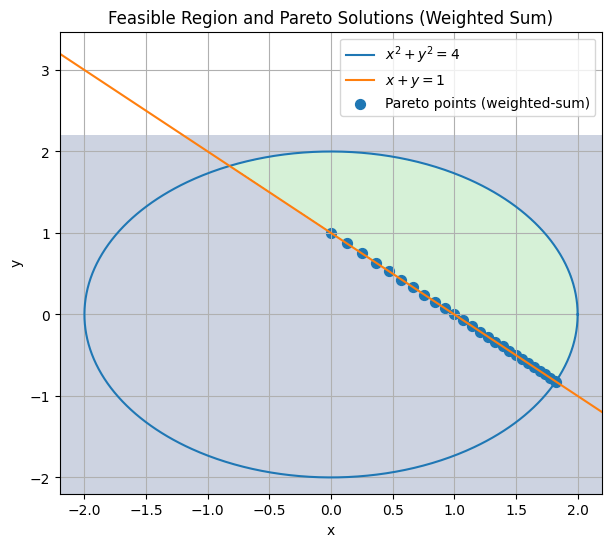

Approximate Pareto solutions (showing first 10 rows):
w, x*, y*, f1, f2
0.00, 0.000000, 1.000000, 10.000000, 0.000000
0.03, 0.129032, 0.870968, 9.001041, 0.016649
0.07, 0.250000, 0.750000, 8.125000, 0.062500
0.10, 0.363636, 0.636364, 7.355372, 0.132231
0.13, 0.470588, 0.529412, 6.678201, 0.221453
0.17, 0.571429, 0.428571, 6.081633, 0.326531
0.20, 0.666667, 0.333333, 5.555556, 0.444444
0.23, 0.756757, 0.243243, 5.091308, 0.572681
0.27, 0.842105, 0.157895, 4.681440, 0.709141
0.30, 0.923077, 0.076923, 4.319527, 0.852071

Extreme solution minimizing f2 (w=0):
success: True
x*, y* = [0. 1.]
f1 = 10.0 f2 = 0.0

Extreme solution minimizing f1 (w=1):
success: True
x*, y* = [ 1.82287567 -0.82287567]
f1 = 2.0627460559606585 f2 = 3.322875711340828


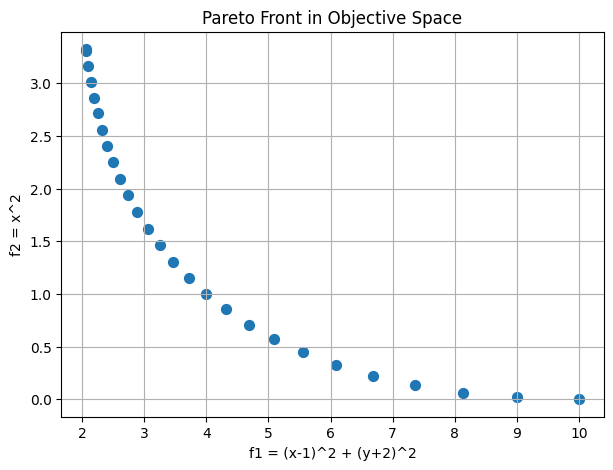

In [19]:
#vector objective components
def f1(xy):
    x, y = xy
    return (x - 1)**2 + (y + 2)**2

def f2(xy):
    x, y = xy
    return x**2

#weighted-sum scalar objective
def J(xy, w):
    return w * f1(xy) + (1 - w) * f2(xy)

#constraints:
#1) x + y >= 1   ->  (x + y - 1) >= 0
#2) x^2 + y^2 <= 4 -> (4 - x^2 - y^2) >= 0
#sciPy uses form: constraint_fun(x) >= 0 for 'ineq'
cons = [
    {"type": "ineq", "fun": lambda xy: (xy[0] + xy[1] - 1)},          # x + y - 1 >= 0
    {"type": "ineq", "fun": lambda xy: (4 - (xy[0]**2 + xy[1]**2))}   # 4 - (x^2 + y^2) >= 0
]

#feasible region plot
#grid for feasibility shading
xx = np.linspace(-2.2, 2.2, 600)
yy = np.linspace(-2.2, 2.2, 600)
X, Y = np.meshgrid(xx, yy)

feasible = (X + Y >= 1) & (X**2 + Y**2 <= 4)

plt.figure(figsize=(7, 6))
plt.contourf(X, Y, feasible, levels=[-0.5, 0.5, 1.5], alpha=0.25)

#boundary circle x^2 + y^2 = 4
theta = np.linspace(0, 2*np.pi, 800)
plt.plot(2*np.cos(theta), 2*np.sin(theta), label=r"$x^2+y^2=4$")

#boundary line x + y = 1  -> y = 1 - x
plt.plot(xx, 1 - xx, label=r"$x+y=1$")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Feasible Region and Pareto Solutions (Weighted Sum)")
plt.grid(True)

#solve for a range of weights to approximate Pareto front
weights = np.linspace(0, 1, 31)  # 31 points from 0 to 1
solutions = []

#few different starting points to improve robustness
x0_list = [
    np.array([0.0, 1.0]),
    np.array([1.5, 0.0]),
    np.array([1.8, -0.8]),
    np.array([0.5, 0.5]),
]

for w in weights:
    best = None
    best_val = np.inf

    for x0 in x0_list:
        res = minimize(lambda z: J(z, w), x0=x0, constraints=cons, method="SLSQP")
        if res.success and res.fun < best_val:
            best_val = res.fun
            best = res

    if best is not None:
        x_star, y_star = best.x
        solutions.append([w, x_star, y_star, f1(best.x), f2(best.x)])

solutions = np.array(solutions)

#remove near-duplicate points (optional cleanup)
#keeping unique-ish points by rounding
if len(solutions) > 0:
    uniq = {}
    for row in solutions:
        key = (round(row[1], 4), round(row[2], 4))
        uniq[key] = row
    solutions = np.array(list(uniq.values()))

#sort by x for a clean curve
solutions = solutions[np.argsort(solutions[:, 1])]

#plot Pareto points in feasible region
plt.scatter(solutions[:, 1], solutions[:, 2], s=50, label="Pareto points (weighted-sum)")
plt.legend()
plt.show()

#printing key results
print("Approximate Pareto solutions (showing first 10 rows):")
print("w, x*, y*, f1, f2")
for row in solutions[:10]:
    print(f"{row[0]:.2f}, {row[1]:.6f}, {row[2]:.6f}, {row[3]:.6f}, {row[4]:.6f}")

#extreme 1: minimize f2 (x^2) -> choose w=0 (pure f2)
#extreme 2: minimize f1 -> choose w=1 (pure f1)
def solve_extreme(w, x0=np.array([0.0, 1.0])):
    res = minimize(lambda z: J(z, w), x0=x0, constraints=cons, method="SLSQP")
    return res

res_f2 = solve_extreme(0.0, np.array([0.0, 1.0]))
res_f1 = solve_extreme(1.0, np.array([1.8, -0.8]))

print("\nExtreme solution minimizing f2 (w=0):")
print("success:", res_f2.success)
print("x*, y* =", res_f2.x)
print("f1 =", f1(res_f2.x), "f2 =", f2(res_f2.x))

print("\nExtreme solution minimizing f1 (w=1):")
print("success:", res_f1.success)
print("x*, y* =", res_f1.x)
print("f1 =", f1(res_f1.x), "f2 =", f2(res_f1.x))

#plot Pareto curve in objective space (f1 vs f2)
plt.figure(figsize=(7, 5))
plt.scatter(solutions[:, 3], solutions[:, 4], s=50)
plt.xlabel("f1 = (x-1)^2 + (y+2)^2")
plt.ylabel("f2 = x^2")
plt.title("Pareto Front in Objective Space")
plt.grid(True)
plt.show()


### Methodology (Bonus: Vector-Valued Optimization)

The objective function is vector-valued:
f(x,y) = ( f1(x,y), f2(x,y) ),
where
f1(x,y) = (x − 1)^2 + (y + 2)^2
and
f2(x,y) = x^2.

Since a vector objective does not have a single minimum in general, the
problem was treated as a Pareto optimization problem.

To approximate the Pareto-optimal set, the weighted-sum method was used.
For each weight w in the interval [0, 1], a scalar objective was formed:
J_w(x,y) = w*f1(x,y) + (1 − w)*f2(x,y).
Each resulting constrained minimization problem was solved using
`scipy.optimize.minimize` with the SLSQP method.

The constraints were implemented as inequalities:
x + y >= 1  
x^2 + y^2 <= 4  

The feasible region was visualized by plotting the boundary circle
x^2 + y^2 = 4 and the line x + y = 1, and shading their intersection.
The resulting Pareto solutions were plotted in:
(1) decision space (x, y)
(2) objective space (f1, f2),
to illustrate the trade-off between minimizing f1 and minimizing f2.
